In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Datanın oxunması, müvafiq xarakteristik məlumatların çıxarılması

In [2]:
df=pd.read_csv(r"C:\Users\Lala\Downloads\archive\vgsales.csv")

In [3]:
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [4]:
df.dtypes

Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [5]:
df.shape

(16598, 11)

In [6]:
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [9]:
df=df.dropna(subset= ['Year'])

In [11]:
df.isnull().sum()

Rank             0
Name             0
Platform         0
Year             0
Genre            0
Publisher       36
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Global_Sales     0
dtype: int64

In [15]:
df['Publisher']=df['Publisher'].fillna('Unknown')

C:\Users\Lala\AppData\Local\Temp\ipykernel_17132\2093570147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Publisher']=df['Publisher'].fillna('Unknown')


In [17]:
df.isnull().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

## Genre kateqoriyasına görə ən çox olunan 10 total satışın tapılması

In [20]:
total_GlobalSales_by_genre= df.groupby('Genre')['Global_Sales'].sum()

In [21]:
total_GlobalSales_by_genre

Genre
Action          1722.88
Adventure        234.80
Fighting         444.05
Misc             797.62
Platform         829.15
Puzzle           242.22
Racing           726.77
Role-Playing     923.84
Shooter         1026.20
Simulation       390.16
Sports          1309.24
Strategy         173.43
Name: Global_Sales, dtype: float64

In [22]:
total_GlobalSales_by_genre= df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending= False)

In [23]:
total_GlobalSales_by_genre.head(10)

Genre
Action          1722.88
Sports          1309.24
Shooter         1026.20
Role-Playing     923.84
Platform         829.15
Misc             797.62
Racing           726.77
Fighting         444.05
Simulation       390.16
Puzzle           242.22
Name: Global_Sales, dtype: float64

## Platform kateqoriyasına görə ən çox olunan 10 total satışın tapılması

In [24]:
total_GlobalSales_by_Platform=df.groupby('Platform')['Global_Sales'].sum()

In [25]:
total_GlobalSales_by_Platform

Platform
2600      86.57
3DO        0.10
3DS      246.28
DC        15.97
DS       818.96
GB       254.42
GBA      313.56
GC       197.14
GEN       28.36
GG         0.04
N64      218.21
NES      251.07
NG         1.44
PC       255.05
PCFX       0.03
PS       727.39
PS2     1233.46
PS3      949.35
PS4      278.10
PSP      291.71
PSV       61.63
SAT       33.59
SCD        1.87
SNES     200.05
TG16       0.16
WS         1.42
Wii      909.81
WiiU      81.86
X360     969.61
XB       252.09
XOne     141.06
Name: Global_Sales, dtype: float64

In [26]:
total_GlobalSales_by_Platform= df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending= False)

In [27]:
total_GlobalSales_by_Platform.head(10)

Platform
PS2     1233.46
X360     969.61
PS3      949.35
Wii      909.81
DS       818.96
PS       727.39
GBA      313.56
PSP      291.71
PS4      278.10
PC       255.05
Name: Global_Sales, dtype: float64

## Publisher kateqoriyasına görə ən çox olunan 10 total satışın tapılması

In [28]:
total_GlobalSales_by_Publisher= df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending= False)

In [29]:
total_GlobalSales_by_Publisher.head(10)

Publisher
Nintendo                        1784.43
Electronic Arts                 1093.39
Activision                       721.41
Sony Computer Entertainment      607.28
Ubisoft                          473.54
Take-Two Interactive             399.30
THQ                              340.44
Konami Digital Entertainment     278.56
Sega                             270.70
Namco Bandai Games               253.65
Name: Global_Sales, dtype: float64

In [30]:
regional_share = (df[["NA_Sales", "EU_Sales", "JP_Sales"]].sum() / df["Global_Sales"].sum()) * 100

In [31]:
regional_share

NA_Sales    49.129854
EU_Sales    27.313171
JP_Sales    14.560630
dtype: float64

In [32]:
na_genre = df.groupby("Genre")["NA_Sales"].sum().sort_values(ascending=False)

In [33]:
na_genre.head(1)

Genre
Action    861.8
Name: NA_Sales, dtype: float64

In [34]:
eu_genre = df.groupby("Genre")["EU_Sales"].sum().sort_values(ascending=False)

In [35]:
eu_genre.head(1)

Genre
Action    516.48
Name: EU_Sales, dtype: float64

In [36]:
jp_genre = df.groupby("Genre")["JP_Sales"].sum().sort_values(ascending=False)

In [37]:
jp_genre.head(1)

Genre
Role-Playing    350.29
Name: JP_Sales, dtype: float64

In [38]:
df['Year']=df['Year'].astype(int)

C:\Users\Lala\AppData\Local\Temp\ipykernel_17132\1925074224.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year']=df['Year'].astype(int)


## 1980 ci ildən 2016 cı ilə qədər olan total global satışlar

In [47]:
yearly_global_sales= (df[(df['Year']>=1980) & (df['Year']<= 2016)]).groupby('Year')['Global_Sales'].sum()

In [48]:
yearly_global_sales

Year
1980     11.38
1981     35.77
1982     28.86
1983     16.79
1984     50.36
1985     53.94
1986     37.07
1987     21.74
1988     47.22
1989     73.45
1990     49.39
1991     32.23
1992     76.16
1993     45.98
1994     79.17
1995     88.11
1996    199.15
1997    200.98
1998    256.47
1999    251.27
2000    201.56
2001    331.47
2002    395.52
2003    357.85
2004    419.31
2005    459.94
2006    521.04
2007    611.13
2008    678.90
2009    667.30
2010    600.45
2011    515.99
2012    363.54
2013    368.11
2014    337.05
2015    264.44
2016     70.93
Name: Global_Sales, dtype: float64

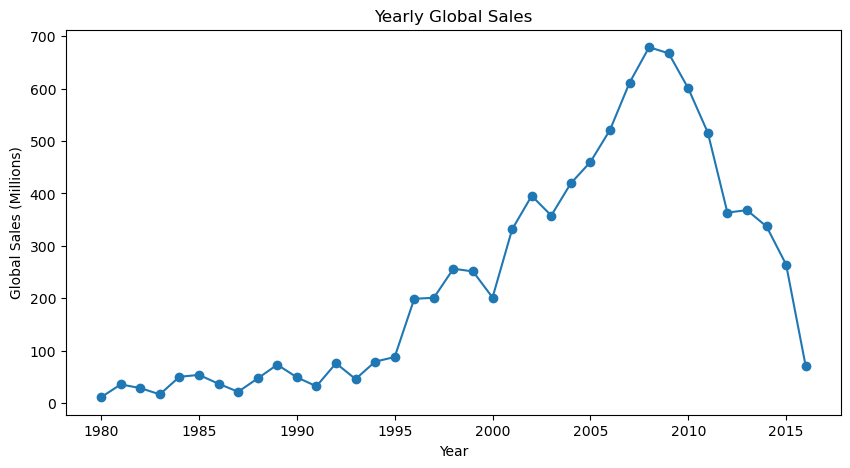

In [53]:
yearly_global_sales.plot(marker="o", figsize=(10,5))
plt.title("Yearly Global Sales")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.show()

##  Qrafikdən görürük ki , 1980 ci ildən 2010 cu ilə kimi satışlarda əhəmiyyətli dərəcədə artım müşahidə olunub lakin sonrakı illərdə enmələr baş verib

In [54]:
top_games = df[["Name","Platform","Genre","Global_Sales"]]
top_games = top_games.sort_values(by="Global_Sales",ascending=False)


In [55]:
top_games.head(10)

,Name,Platform,Genre,Global_Sales
0,Wii Sports,Wii,Sports,82.74
1,Super Mario Bros.,NES,Platform,40.24
2,Mario Kart Wii,Wii,Racing,35.82
3,Wii Sports Resort,Wii,Sports,33.00
4,Pokemon Red/Pokemon Blue,GB,Role-Playing,31.37
5,Tetris,GB,Puzzle,30.26
6,New Super Mario Bros.,DS,Platform,30.01
7,Wii Play,Wii,Misc,29.02
8,New Super Mario Bros. Wii,Wii,Platform,28.62
9,Duck Hunt,NES,Shooter,28.31


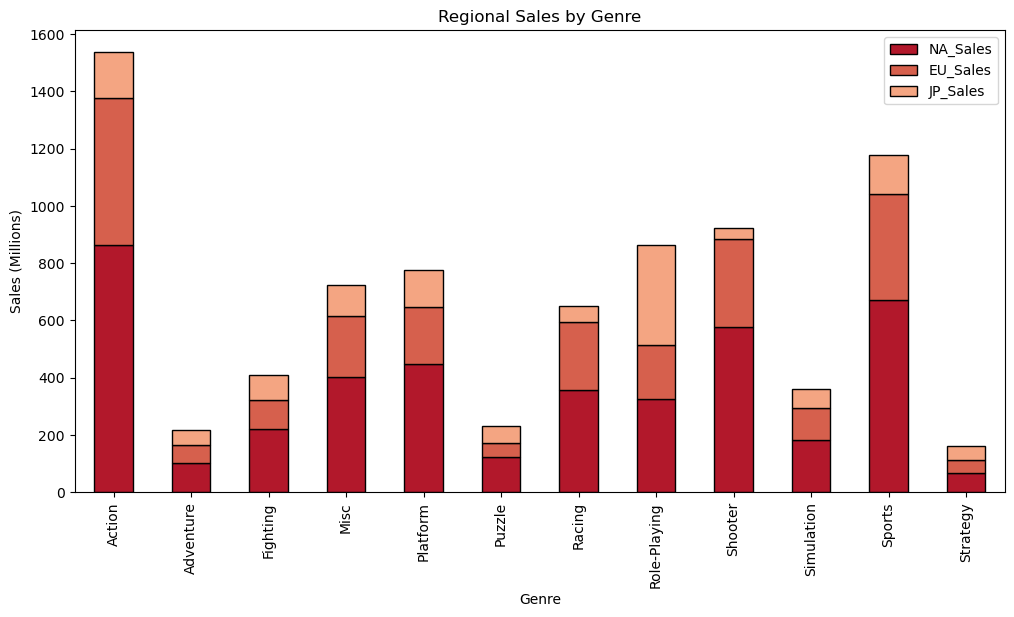

In [58]:
genre_region = df.groupby("Genre")[["NA_Sales","EU_Sales","JP_Sales"]].sum()
colors=['#B2182B','#D6604D','#F4A582']
genre_region.plot(kind="bar",stacked=True, figsize=(12,6),color=colors,edgecolor='black')
plt.title("Regional Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Sales (Millions)")
plt.show()

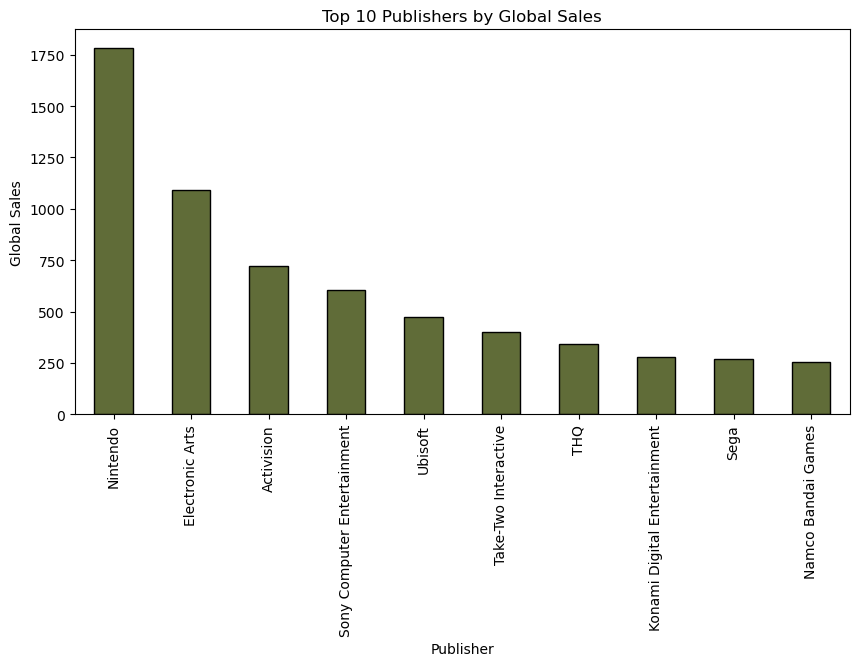

In [63]:
total_GlobalSales_by_Publisher.head(10).plot(kind="bar",figsize=(10,5),color='#606C38',edgecolor='black')
plt.title("Top 10 Publishers by Global Sales")
plt.xlabel("Publisher")
plt.ylabel("Global Sales")
plt.show()

# Business Insights

### North America is the largest video game market, while Japan shows noticeably different genre preferences.
### Action and Sports games dominate sales in North America and Europe, whereas Role-Playing games are much more popular in Japan.
### Global game sales grew rapidly until the late 2000s before gradually declining, reflecting changes in the gaming industry.
### A small number of major publishers account for a significant share of total global game sales, highlighting their strong market influence.

### ------------------

### Şimali Amerika ən böyük video oyun bazarıdır, Yaponiyada isə oyun janrına olan maraq digər regionlardan fərqlənir.
### Action və Sports janrları Şimali Amerika və Avropada daha populyardır, Role-Playing janrı isə Yaponiyada üstünlük təşkil edir.
### Qlobal oyun satışları 2000-ci illərin sonlarına qədər sürətlə artıb, daha sonra isə tədricən azalma müşahidə olunub.
### Ümumi satışların böyük hissəsi az sayda iri nəşriyyatın payına düşür ki, bu da onların bazarda güclü mövqeyə sahib olduğunu göstərir.

# BONUS 1

In [64]:
df["Decade"] = (df["Year"] // 10 * 10).astype(int).astype(str) + "s"
decade_sales = ( df[(df["Year"] >= 1980) & (df["Year"] <= 2016)].groupby("Decade")["Global_Sales"].mean().sort_values(ascending=False))



C:\Users\Lala\AppData\Local\Temp\ipykernel_17132\457759696.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Decade"] = (df["Year"] // 10 * 10).astype(int).astype(str) + "s"


In [65]:
decade_sales

Decade
1980s    1.836976
1990s    0.722956
2000s    0.504346
2010s    0.490276
Name: Global_Sales, dtype: float64

# BONUS 2

In [69]:
top5_genres =df.groupby("Genre")["Global_Sales"] .sum().sort_values(ascending=False).head(5)

In [70]:
top5_genres

Genre
Action          1722.88
Sports          1309.24
Shooter         1026.20
Role-Playing     923.84
Platform         829.15
Name: Global_Sales, dtype: float64

In [74]:
genre_region =(df[df["Genre"].isin(top5_genres.index)] .groupby("Genre")[["NA_Sales", "EU_Sales", "JP_Sales"]].sum())

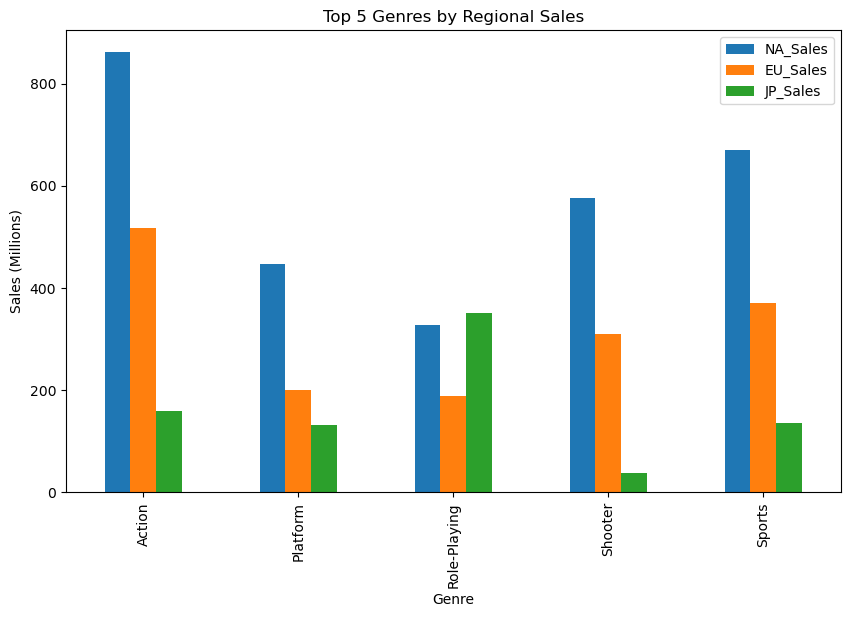

In [75]:
genre_region.plot(kind="bar", figsize=(10,6),color=co)
colors=['#780000','#c1121f','#fdf0d5']
plt.title("Top 5 Genres by Regional Sales")
plt.xlabel("Genre")
plt.ylabel("Sales (Millions)")
plt.show()